# Практическая работа №2
## Моделирование многоканальной системы с ожиданием

**Тема моделирования:** пункт выдачи заказов

В работе рассматривается ПВЗ, в котором есть несколько окон обслуживания. Если в момент прихода клиента хотя бы одно окно свободно, клиент сразу начинает обслуживание. Если все окна заняты, клиент становится в очередь и ожидает освобождения одного из окон.

### Обозначения
- $\lambda$ — интенсивность входящего потока клиентов;
- $\mu$ — интенсивность обслуживания одним окном;
- $n$ — количество окон обслуживания;
- $\infty$ — длина очереди не ограничена.



## 1. Описание модели

Рассматривается многоканальная система массового обслуживания с ожиданием типа `M/M/n/∞`.

Основные предположения модели:
- входной поток клиентов является пуассоновским;
- время обслуживания распределено по экспоненциальному закону;
- обслуживание ведётся по принципу FIFO;
- если все окна заняты, клиент становится в очередь;
- длина очереди не ограничена.

### Состояния системы
Состояние системы определяется общим числом клиентов в системе:
- если число клиентов меньше $n$, часть окон свободна;
- если число клиентов больше или равно $n$, все окна заняты, а остальные клиенты образуют очередь.

### Условие устойчивости
Система работает устойчиво, если

$$
\rho = \frac{\lambda}{n\mu} < 1.
$$

Если это условие не выполняется, очередь будет неограниченно расти.

In [30]:
import heapq
from collections import deque
from math import factorial

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

## 2. Теоретический расчёт характеристик

Для системы `M/M/n/∞` используются следующие формулы.

Обозначим

$$
a = \frac{\lambda}{\mu}, \qquad \rho = \frac{\lambda}{n\mu}.
$$

Вероятность простоя системы:

$$
P_0 = \left( \sum_{k=0}^{n-1} \frac{a^k}{k!} + \frac{a^n}{n!(1-\rho)} \right)^{-1}.
$$

Вероятность того, что заявка будет ждать в очереди:

$$
P_{\text{ож}} = \frac{a^n}{n!(1-\rho)} P_0.
$$

Среднее число заявок в очереди:

$$
L_q = \frac{P_0 a^n \rho}{n!(1-\rho)^2}.
$$

Среднее время ожидания в очереди:

$$
W_q = \frac{L_q}{\lambda}.
$$

Среднее время пребывания в системе:

$$
W = W_q + \frac{1}{\mu}.
$$

Среднее число заявок в системе:

$$
L = \lambda W.
$$

Коэффициент загрузки системы:

$$
\rho = \frac{\lambda}{n\mu}.
$$

In [31]:
def theoretical_data(lmbda, mu, n):
    rho = lmbda / (n * mu)
    if rho >= 1:
        raise ValueError('Система неустойчива: требуется rho < 1')

    a = lmbda / mu
    sum_part = sum((a ** k) / factorial(k) for k in range(n))
    tail_part = (a ** n) / (factorial(n) * (1 - rho))

    P0 = 1 / (sum_part + tail_part)
    P_wait = ((a ** n) / (factorial(n) * (1 - rho))) * P0
    Lq = (P0 * (a ** n) * rho) / (factorial(n) * (1 - rho) ** 2)
    Wq = Lq / lmbda
    W = Wq + 1 / mu
    L = lmbda * W

    return {
        'lambda': lmbda,
        'mu': mu,
        'n': n,
        'rho': rho,
        'P0_theor': P0,
        'P_wait_theor': P_wait,
        'Lq_theor': Lq,
        'Wq_theor': Wq,
        'W_theor': W,
        'L_theor': L,
    }

## 3. Имитационная модель пункта выдачи заказов

В каждый момент времени рассматриваются два типа событий:
1. приход нового клиента;
2. окончание обслуживания одним из окон.

Если свободное окно есть, клиент сразу начинает обслуживаться.
Если свободных окон нет, клиент становится в очередь.

В имитационной модели дополнительно накапливаются интегральные характеристики по времени:
- доля времени пустой системы;
- средняя длина очереди;
- среднее число занятых окон.

За счёт этого можно получить экспериментальные оценки показателей и сравнить их с теорией.

In [32]:
def simulate_pickup_point_queue(lmbda, mu, n, T, seed=None):
    rng = np.random.default_rng(seed)

    current_time = 0.0
    last_event_time = 0.0

    next_arrival = rng.exponential(1 / lmbda)
    departure_times = []
    queue = deque()

    arrived = 0
    served = 0
    queued_count = 0

    area_queue = 0.0
    area_busy = 0.0
    area_system_empty = 0.0

    while True:
        next_departure = departure_times[0] if departure_times else np.inf
        next_event_time = min(next_arrival, next_departure)

        if next_event_time > T:
            dt = T - last_event_time
            if dt > 0:
                area_queue += len(queue) * dt
                area_busy += len(departure_times) * dt
                if len(queue) == 0 and len(departure_times) == 0:
                    area_system_empty += dt
            break

        current_time = next_event_time
        dt = current_time - last_event_time

        area_queue += len(queue) * dt
        area_busy += len(departure_times) * dt
        if len(queue) == 0 and len(departure_times) == 0:
            area_system_empty += dt

        last_event_time = current_time

        if next_arrival <= next_departure:
            arrived += 1

            if len(departure_times) < n:
                service_time = rng.exponential(1 / mu)
                heapq.heappush(departure_times, current_time + service_time)
            else:
                queue.append(current_time)
                queued_count += 1

            next_arrival = current_time + rng.exponential(1 / lmbda)
        else:
            heapq.heappop(departure_times)
            served += 1

            if queue:
                queue.popleft()
                service_time = rng.exponential(1 / mu)
                heapq.heappush(departure_times, current_time + service_time)

    lambda_exp = arrived / T if T > 0 else 0.0
    P0_exp = area_system_empty / T
    P_wait_exp = queued_count / arrived if arrived > 0 else 0.0
    Lq_exp = area_queue / T
    L_exp = (area_queue + area_busy) / T
    Wq_exp = Lq_exp / lambda_exp if lambda_exp > 0 else 0.0
    W_exp = L_exp / lambda_exp if lambda_exp > 0 else 0.0
    rho_exp = area_busy / (n * T)

    return {
        'lambda': lmbda,
        'mu': mu,
        'n': n,
        'T': T,
        'arrived': arrived,
        'served': served,
        'P0_exp': P0_exp,
        'P_wait_exp': P_wait_exp,
        'Lq_exp': Lq_exp,
        'Wq_exp': Wq_exp,
        'W_exp': W_exp,
        'L_exp': L_exp,
        'rho_exp': rho_exp,
    }

## 4. Усреднение по нескольким прогонам

Один прогон имитационной модели зависит от случайных величин, поэтому его результат может немного колебаться.
Чтобы уменьшить влияние случайности, моделирование выполняется несколько раз с разными значениями `seed`, после чего результаты усредняются.

В работе используется усреднение по **30 прогонам**.

In [33]:
def run_experiment_avg(lmbda, mu, n, T, n_runs=30, base_seed=1000):
    metrics = {
        'P0_exp': [],
        'P_wait_exp': [],
        'Lq_exp': [],
        'Wq_exp': [],
        'W_exp': [],
        'L_exp': [],
        'rho_exp': [],
    }

    for run in range(n_runs):
        seed = base_seed + run
        result = simulate_pickup_point_queue(lmbda, mu, n, T, seed=seed)
        for key in metrics:
            metrics[key].append(result[key])

    avg_result = {
        'lambda': lmbda,
        'mu': mu,
        'n': n,
        'T': T,
        'n_runs': n_runs,
    }

    for key in metrics:
        avg_result[key] = float(np.mean(metrics[key]))
        avg_result[key + '_std'] = float(np.std(metrics[key]))

    return avg_result, metrics

## 5. Эксперимент: влияние количества окон обслуживания

Фиксируем:
- $\lambda = 18$ клиентов в час;
- $\mu = 12$ клиентов в час на одно окно;
- время моделирования $T = 1000$ часов;
- усреднение по 30 прогонам.

Будем изменять количество окон $n$ от 2 до 5

In [34]:
lmbda = 18
mu = 12
T = 1000
n_runs = 30

n_values = np.arange(2, 6)

table_n = []

exp_P0_n, theor_P0_n = [], []
exp_Pwait_n, theor_Pwait_n = [], []
exp_Lq_n, theor_Lq_n = [], []
exp_Wq_n, theor_Wq_n = [], []
exp_W_n, theor_W_n = [], []
exp_rho_n, theor_rho_n = [], []

for n in n_values:
    exp_avg, _ = run_experiment_avg(lmbda, mu, n, T, n_runs=n_runs, base_seed=1000 + 100 * n)
    theor = theoretical_data(lmbda, mu, n)

    table_n.append([
        n,
        lmbda,
        mu,
        exp_avg['P0_exp'],
        theor['P0_theor'],
        exp_avg['P_wait_exp'],
        theor['P_wait_theor'],
        exp_avg['Lq_exp'],
        theor['Lq_theor'],
        exp_avg['Wq_exp'] * 60,
        theor['Wq_theor'] * 60,
        exp_avg['W_exp'] * 60,
        theor['W_theor'] * 60,
        exp_avg['rho_exp'],
        theor['rho'],
    ])

    exp_P0_n.append(exp_avg['P0_exp'])
    theor_P0_n.append(theor['P0_theor'])
    exp_Pwait_n.append(exp_avg['P_wait_exp'])
    theor_Pwait_n.append(theor['P_wait_theor'])
    exp_Lq_n.append(exp_avg['Lq_exp'])
    theor_Lq_n.append(theor['Lq_theor'])
    exp_Wq_n.append(exp_avg['Wq_exp'] * 60)
    theor_Wq_n.append(theor['Wq_theor'] * 60)
    exp_W_n.append(exp_avg['W_exp'] * 60)
    theor_W_n.append(theor['W_theor'] * 60)
    exp_rho_n.append(exp_avg['rho_exp'])
    theor_rho_n.append(theor['rho'])

df_n = pd.DataFrame(
    table_n,
    columns=[
        'n', 'λ', 'μ',
        'P0 (э)', 'P0 (т)',
        'Pож (э)', 'Pож (т)',
        'Lq (э)', 'Lq (т)',
        'Wq, мин (э)', 'Wq, мин (т)',
        'W, мин (э)', 'W, мин (т)',
        'ρ (э)', 'ρ (т)',
    ],
)
df_n.round(4)

,n,λ,μ,P0 (э),P0 (т),Pож (э),Pож (т),Lq (э),Lq (т),"Wq, мин (э)","Wq, мин (т)","W, мин (э)","W, мин (т)",ρ (э),ρ (т)
0,2,18,12,0.1423,0.1429,0.6431,0.6429,1.9382,1.9286,6.4564,6.4286,11.4585,11.4286,0.7506,0.750
1,3,18,12,0.2108,0.2105,0.2368,0.2368,0.2377,0.2368,0.7934,0.7895,5.8001,5.7895,0.4999,0.500
2,4,18,12,0.2204,0.2210,0.0746,0.0746,0.0445,0.0448,0.1480,0.1492,5.1527,5.1492,0.3759,0.375
3,5,18,12,0.2224,0.2228,0.0204,0.0201,0.0086,0.0086,0.0288,0.0288,5.0410,5.0288,0.3007,0.300


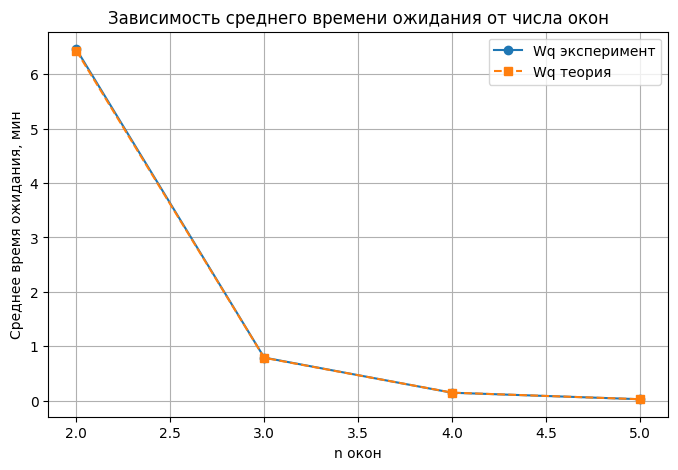

In [35]:
plt.figure(figsize=(8, 5))
plt.plot(n_values, exp_Wq_n, marker='o', label='Wq эксперимент')
plt.plot(n_values, theor_Wq_n, marker='s', linestyle='--', label='Wq теория')
plt.xlabel('n окон')
plt.ylabel('Среднее время ожидания, мин')
plt.title('Зависимость среднего времени ожидания от числа окон')
plt.grid(True)
plt.legend()
plt.show()

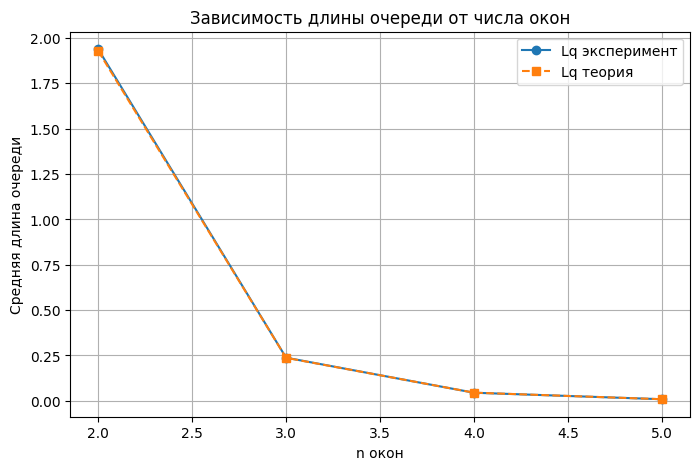

In [36]:
plt.figure(figsize=(8, 5))
plt.plot(n_values, exp_Lq_n, marker='o', label='Lq эксперимент')
plt.plot(n_values, theor_Lq_n, marker='s', linestyle='--', label='Lq теория')
plt.xlabel('n окон')
plt.ylabel('Средняя длина очереди')
plt.title('Зависимость длины очереди от числа окон')
plt.grid(True)
plt.legend()
plt.show()

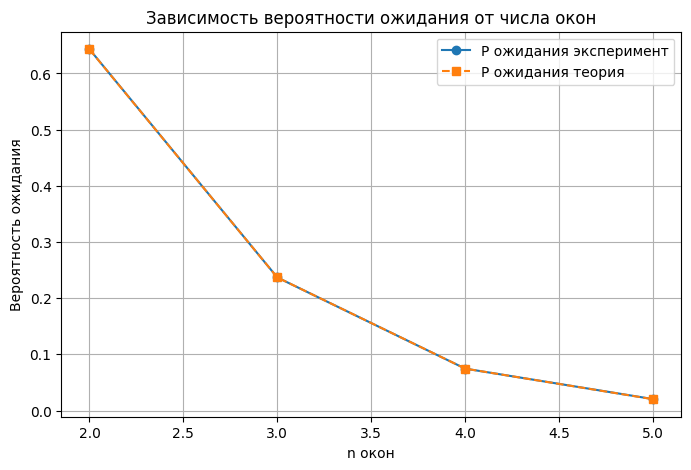

In [37]:
plt.figure(figsize=(8, 5))
plt.plot(n_values, exp_Pwait_n, marker='o', label='P ожидания эксперимент')
plt.plot(n_values, theor_Pwait_n, marker='s', linestyle='--', label='P ожидания теория')
plt.xlabel('n окон')
plt.ylabel('Вероятность ожидания')
plt.title('Зависимость вероятности ожидания от числа окон')
plt.grid(True)
plt.legend()
plt.show()

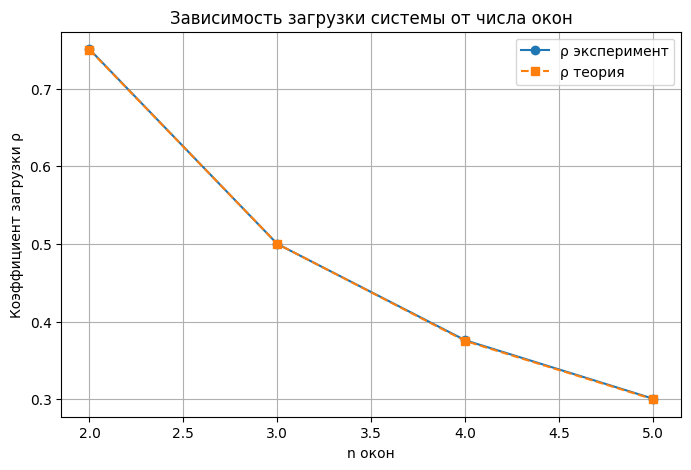

In [38]:
plt.figure(figsize=(8, 5))
plt.plot(n_values, exp_rho_n, marker='o', label='ρ эксперимент')
plt.plot(n_values, theor_rho_n, marker='s', linestyle='--', label='ρ теория')
plt.xlabel('n окон')
plt.ylabel('Коэффициент загрузки ρ')
plt.title('Зависимость загрузки системы от числа окон')
plt.grid(True)
plt.legend()
plt.show()

## 6. Эксперимент: влияние интенсивности обслуживания

Теперь фиксируем:
- $\lambda = 18$ клиентов в час;
- $n = 3$ окна;
- время моделирования $T = 1000$ часов;
- усреднение по 30 прогонам.

Будем изменять интенсивность обслуживания $\mu$ от 8 до 14 клиентов в час на одно окно.

Такой диапазон выбран специально:
- при меньшем $\mu$ система уже становится слишком тяжёлой;
- при большем $\mu$ ожидание почти исчезает и различия становятся слишком малы.

In [39]:
lmbda = 18
n = 3
T = 1000
n_runs = 30

mu_values = np.arange(8, 15)

table_mu = []

exp_P0_mu, theor_P0_mu = [], []
exp_Pwait_mu, theor_Pwait_mu = [], []
exp_Lq_mu, theor_Lq_mu = [], []
exp_Wq_mu, theor_Wq_mu = [], []
exp_W_mu, theor_W_mu = [], []
exp_rho_mu, theor_rho_mu = [], []

for mu_val in mu_values:
    exp_avg, _ = run_experiment_avg(lmbda, mu_val, n, T, n_runs=n_runs, base_seed=5000 + 100 * mu_val)
    theor = theoretical_data(lmbda, mu_val, n)

    table_mu.append([
        mu_val,
        lmbda,
        n,
        exp_avg['P0_exp'],
        theor['P0_theor'],
        exp_avg['P_wait_exp'],
        theor['P_wait_theor'],
        exp_avg['Lq_exp'],
        theor['Lq_theor'],
        exp_avg['Wq_exp'] * 60,
        theor['Wq_theor'] * 60,
        exp_avg['W_exp'] * 60,
        theor['W_theor'] * 60,
        exp_avg['rho_exp'],
        theor['rho'],
    ])

    exp_P0_mu.append(exp_avg['P0_exp'])
    theor_P0_mu.append(theor['P0_theor'])
    exp_Pwait_mu.append(exp_avg['P_wait_exp'])
    theor_Pwait_mu.append(theor['P_wait_theor'])
    exp_Lq_mu.append(exp_avg['Lq_exp'])
    theor_Lq_mu.append(theor['Lq_theor'])
    exp_Wq_mu.append(exp_avg['Wq_exp'] * 60)
    theor_Wq_mu.append(theor['Wq_theor'] * 60)
    exp_W_mu.append(exp_avg['W_exp'] * 60)
    theor_W_mu.append(theor['W_theor'] * 60)
    exp_rho_mu.append(exp_avg['rho_exp'])
    theor_rho_mu.append(theor['rho'])

df_mu = pd.DataFrame(
    table_mu,
    columns=[
        'μ', 'λ', 'n',
        'P0 (э)', 'P0 (т)',
        'Pож (э)', 'Pож (т)',
        'Lq (э)', 'Lq (т)',
        'Wq, мин (э)', 'Wq, мин (т)',
        'W, мин (э)', 'W, мин (т)',
        'ρ (э)', 'ρ (т)',
    ],
)
df_mu.round(4)

,μ,λ,n,P0 (э),P0 (т),Pож (э),Pож (т),Lq (э),Lq (т),"Wq, мин (э)","Wq, мин (т)","W, мин (э)","W, мин (т)",ρ (э),ρ (т)
0,8,18,3,0.0754,0.0748,0.5624,0.5678,1.6740,1.7033,5.5839,5.6776,13.0610,13.1776,0.7471,0.7500
1,9,18,3,0.1102,0.1111,0.4479,0.4444,0.9020,0.8889,3.0046,2.9630,9.6888,9.6296,0.6687,0.6667
2,10,18,3,0.1464,0.1460,0.3546,0.3547,0.5307,0.5321,1.7736,1.7737,7.7852,7.7737,0.5995,0.6000
3,11,18,3,0.1792,0.1792,0.2870,0.2878,0.3429,0.3454,1.1440,1.1513,6.6000,6.6059,0.5451,0.5455
4,12,18,3,0.2098,0.2105,0.2371,0.2368,0.2397,0.2368,0.7989,0.7895,5.8042,5.7895,0.5007,0.5000
5,13,18,3,0.2410,0.2401,0.1974,0.1973,0.1722,0.1691,0.5738,0.5637,5.1865,5.1790,0.4613,0.4615
6,14,18,3,0.2671,0.2679,0.1675,0.1661,0.1266,0.1246,0.4213,0.4152,4.7157,4.7010,0.4302,0.4286


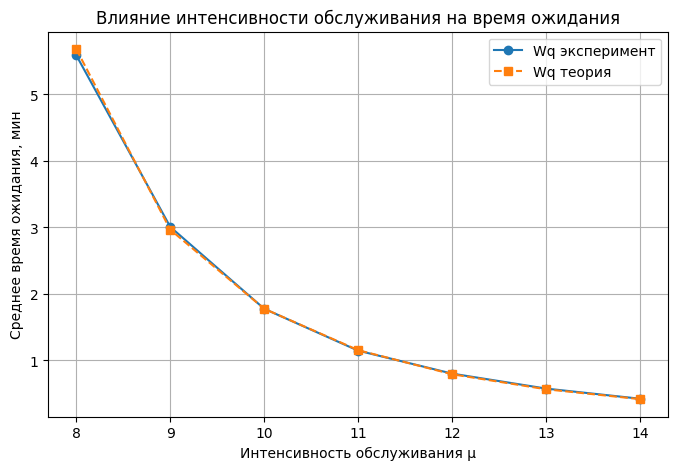

In [40]:
plt.figure(figsize=(8, 5))
plt.plot(mu_values, exp_Wq_mu, marker='o', label='Wq эксперимент')
plt.plot(mu_values, theor_Wq_mu, marker='s', linestyle='--', label='Wq теория')
plt.xlabel('Интенсивность обслуживания μ')
plt.ylabel('Среднее время ожидания, мин')
plt.title('Влияние интенсивности обслуживания на время ожидания')
plt.grid(True)
plt.legend()
plt.show()

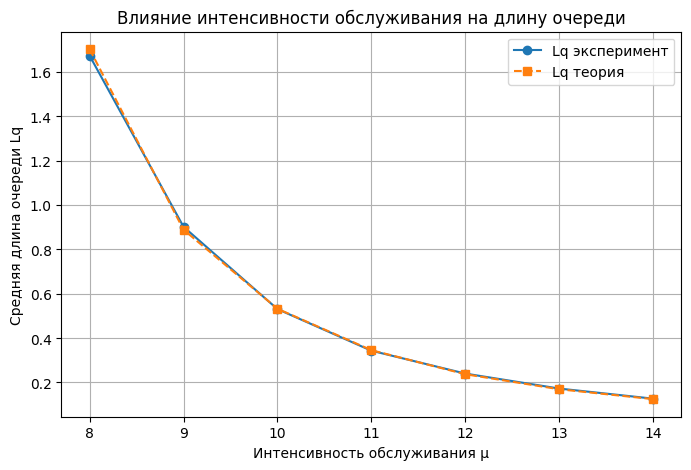

In [41]:
plt.figure(figsize=(8, 5))
plt.plot(mu_values, exp_Lq_mu, marker='o', label='Lq эксперимент')
plt.plot(mu_values, theor_Lq_mu, marker='s', linestyle='--', label='Lq теория')
plt.xlabel('Интенсивность обслуживания μ')
plt.ylabel('Средняя длина очереди Lq')
plt.title('Влияние интенсивности обслуживания на длину очереди')
plt.grid(True)
plt.legend()
plt.show()

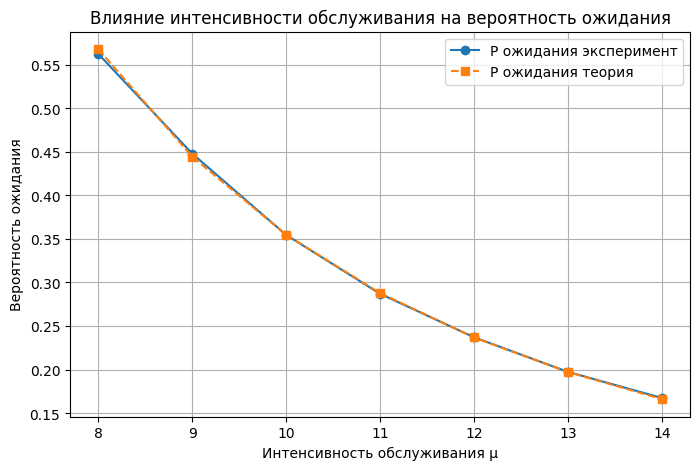

In [42]:
plt.figure(figsize=(8, 5))
plt.plot(mu_values, exp_Pwait_mu, marker='o', label='P ожидания эксперимент')
plt.plot(mu_values, theor_Pwait_mu, marker='s', linestyle='--', label='P ожидания теория')
plt.xlabel('Интенсивность обслуживания μ')
plt.ylabel('Вероятность ожидания')
plt.title('Влияние интенсивности обслуживания на вероятность ожидания')
plt.grid(True)
plt.legend()
plt.show()

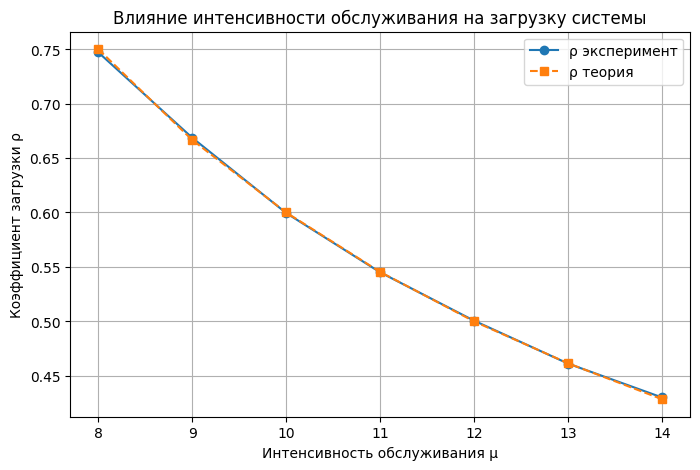

In [43]:
plt.figure(figsize=(8, 5))
plt.plot(mu_values, exp_rho_mu, marker='o', label='ρ эксперимент')
plt.plot(mu_values, theor_rho_mu, marker='s', linestyle='--', label='ρ теория')
plt.xlabel('Интенсивность обслуживания μ')
plt.ylabel('Коэффициент загрузки ρ')
plt.title('Влияние интенсивности обслуживания на загрузку системы')
plt.grid(True)
plt.legend()
plt.show()

## 7. Краткий анализ результатов

По результатам расчётов и моделирования можно сделать следующие выводы:

1. При увеличении числа окон обслуживания $n$ уменьшаются среднее время ожидания и средняя длина очереди.
2. Для выбранного сценария ПВЗ значение $n = 2$ уже устойчиво, но даёт заметное ожидание клиентов.
3. Значение $n = 3$ выглядит как разумный компромисс между качеством обслуживания и числом окон.
4. Значение $n = 4$ даёт дополнительное улучшение и почти убирает очередь в пиковый час.
5. Значение $n = 5$ ещё сильнее уменьшает ожидание, но прирост по сравнению с $n = 4$ уже небольшой.
6. При увеличении интенсивности обслуживания $\mu$ система работает эффективнее: очередь сокращается, время ожидания уменьшается, вероятность ожидания падает.
7. Коэффициент загрузки системы уменьшается при росте $n$ и $\mu$, так как нагрузка распределяется между большим числом окон или обслуживается быстрее.
8. Экспериментальные результаты близки к теоретическим, что подтверждает корректность модели.

### Итоговый практический вывод
Если интерпретировать модель как ПВЗ Ozon-подобного типа в пиковый час, то наиболее разумным вариантом всё ещё выглядит **3 окна обслуживания**. Два окна ещё создают заметное ожидание, четыре окна уже дают очень комфортный режим, а пятое окно уменьшает ожидание ещё сильнее, но уже с небольшим дополнительным эффектом.